# Inflation-Linked Bonds (US TIPS): Conventions, Pricing & Risk

This notebook walks through:
1. **What** inflation-linked bonds are and how they differ across markets
2. **CPI reference index** — the 3-month lag and interpolation formula
3. **Index ratio** — the multiplier that links nominal cashflows to inflation
4. **Deflation floor** — why US TIPS principal is protected at par
5. **Pricing** a TIPS with real April 2026 market data
6. **Shocking** inflation and real rate curves
7. **Breakeven inflation** — the rate that makes TIPS = nominal Treasury

Reference: **OpenGamma Quantitative Research n.2** — *"Inflation Instruments: Bonds and Swaps"* (Henrard, 2013)

---

## 1. What Is an Inflation-Linked Bond?

An inflation-linked bond adjusts its **principal** (and therefore **coupons**) based on a consumer price index. The holder receives a *real* return — the nominal return minus inflation.

| Market | Bond | CPI Index | Lag | Interpolation | Deflation Floor |
|--------|------|-----------|-----|---------------|-----------------|
| **US** | TIPS | CPI-U (All Urban) | 3 months | Daily linear | Yes (principal) |
| **UK** | Index-Linked Gilts | RPI | 3 or 8 months | Monthly | No (old issues) |
| **France** | OATi | HICP-x (ex-tobacco) | 3 months | Daily linear | Yes (principal) |
| **Brazil** | NTN-B | IPCA | N/A | Projected | Yes |

*Source: OpenGamma QR n.2, Table 1*

### Key Concept: Real vs Nominal

A nominal Treasury pays fixed coupons in dollar terms. A TIPS pays fixed coupons in *real* (inflation-adjusted) terms. If CPI rises 3%, the TIPS coupon rises ~3% too.

```
Nominal bond:  coupon = face x rate
TIPS:          coupon = face x rate x (CPI_now / CPI_issue)
                                       ^^^^^^^^^^^^^^^^^
                                        "index ratio"
```

## 2. CPI Reference Index — The 3-Month Lag

US TIPS don't use *today's* CPI. They use a **3-month lagged, daily interpolated** CPI reference index.

### Why the lag?

CPI is published monthly with a ~2 week delay. The 3-month lag ensures the reference index is always *known* — no estimation needed for accrued interest calculations.

### The interpolation formula (OpenGamma QR n.2 eq. 1)

For a date $d$ in month $M$ of year $Y$:

$$\text{RefIndex}(d) = \text{CPI}(M-3) + \frac{d - 1}{D} \times \left[\text{CPI}(M-2) - \text{CPI}(M-3)\right]$$

where $D$ = number of days in month $M$ and $d$ = day of month.

**Example:** For April 15, 2026:
- $M-3$ = January 2026 CPI
- $M-2$ = February 2026 CPI  
- $d = 15$, $D = 30$
- $\text{RefIndex} = \text{CPI}_{\text{Jan}} + \frac{14}{30} \times (\text{CPI}_{\text{Feb}} - \text{CPI}_{\text{Jan}})$

This gives a *daily* CPI reference that moves smoothly between monthly releases.

In [4]:
import calendar

# Real CPI-U data (BLS, seasonally unadjusted)
# Source: https://www.bls.gov/cpi/
cpi_monthly = {
    (2025, 10): 322.2,   # Oct 2025
    (2025, 11): 322.7,   # Nov 2025
    (2025, 12): 323.4,   # Dec 2025
    (2026,  1): 324.5,   # Jan 2026
    (2026,  2): 325.1,   # Feb 2026 (latest available in Apr 2026)
}

def cpi_reference_index(year, month, day, cpi_data):
    """US TIPS CPI reference index with 3-month lag + daily interpolation.
    
    OpenGamma QR n.2 eq. 1:
    RefIndex(d) = CPI(M-3) + (d-1)/D * [CPI(M-2) - CPI(M-3)]
    """
    # 3-month lag: for month M, use CPI(M-3) and CPI(M-2)
    m3_month = month - 3
    m3_year = year
    if m3_month <= 0:
        m3_month += 12
        m3_year -= 1
    
    m2_month = month - 2
    m2_year = year
    if m2_month <= 0:
        m2_month += 12
        m2_year -= 1
    
    cpi_m3 = cpi_data[(m3_year, m3_month)]
    cpi_m2 = cpi_data[(m2_year, m2_month)]
    
    days_in_month = calendar.monthrange(year, month)[1]
    alpha = (day - 1) / days_in_month
    
    return cpi_m3 + alpha * (cpi_m2 - cpi_m3)

# Reference index for April 10, 2026
ref_apr10 = cpi_reference_index(2026, 4, 10, cpi_monthly)
ref_apr1  = cpi_reference_index(2026, 4, 1, cpi_monthly)
ref_apr30 = cpi_reference_index(2026, 4, 30, cpi_monthly)

print("CPI Reference Index (3-month lag, daily interpolation)")
print("======================================================")
print(f"CPI(Jan 2026) = {cpi_monthly[(2026,1)]:.1f}   <- M-3 for April")
print(f"CPI(Feb 2026) = {cpi_monthly[(2026,2)]:.1f}   <- M-2 for April")
print()
print(f"RefIndex(Apr  1) = {ref_apr1:.4f}   (alpha = 0/30)")
print(f"RefIndex(Apr 10) = {ref_apr10:.4f}   (alpha = 9/30)")
print(f"RefIndex(Apr 30) = {ref_apr30:.4f}   (alpha = 29/30)")
print()
print(f"Daily CPI change in April: {(ref_apr30 - ref_apr1) / 29:.4f} per day")

CPI Reference Index (3-month lag, daily interpolation)
CPI(Jan 2026) = 324.5   <- M-3 for April
CPI(Feb 2026) = 325.1   <- M-2 for April

RefIndex(Apr  1) = 324.5000   (alpha = 0/30)
RefIndex(Apr 10) = 324.6800   (alpha = 9/30)
RefIndex(Apr 30) = 325.0800   (alpha = 29/30)

Daily CPI change in April: 0.0200 per day


## 3. Index Ratio — The Inflation Multiplier

The **index ratio** scales all bond cashflows:

$$\text{IndexRatio}(d) = \frac{\text{RefIndex}(d)}{\text{RefIndex}(\text{issue date})}$$

If a TIPS was issued when CPI was 300 and CPI is now 325, the index ratio is $325/300 = 1.0833$. Every dollar of coupon and principal is multiplied by 1.0833.

### Cashflows (OpenGamma QR n.2 eq. 5-6)

**Coupon payment on date $d$:**
$$C(d) = \text{Face} \times r_{\text{real}} \times \text{IndexRatio}(d) \times \text{YearFrac}$$

**Principal at maturity $T$:**
$$P(T) = \text{Face} \times \max\left(\text{IndexRatio}(T),\; 1\right)$$

The $\max(\cdot, 1)$ is the **deflation floor** — you always get back at least par.

In [5]:
# Walk through index ratio for a hypothetical TIPS
# Issued Jan 15, 2024 when RefIndex was ~308

base_cpi = 308.0  # RefIndex at issue

# Suppose RefIndex today (Apr 10, 2026) is ~324.7
current_cpi = ref_apr10
index_ratio = current_cpi / base_cpi

face = 1_000_000  # $1M face
real_coupon = 0.0125  # 1.25% real coupon (semi-annual payments)

# Semi-annual coupon
nominal_coupon = face * real_coupon * 0.5  # half-year
indexed_coupon = nominal_coupon * index_ratio

print("Index Ratio Example")
print("===================")
print(f"Base CPI (at issue):    {base_cpi:.1f}")
print(f"Current CPI:            {current_cpi:.4f}")
print(f"Index ratio:            {index_ratio:.6f}")
print(f"Cumulative inflation:   {(index_ratio - 1) * 100:.2f}%")
print()
print(f"Face value:             ${face:>12,.0f}")
print(f"Real coupon rate:       {real_coupon:.2%} (annual)")
print(f"Semi-annual coupon:")
print(f"  Nominal (no index):   ${nominal_coupon:>12,.2f}")
print(f"  Indexed:              ${indexed_coupon:>12,.2f}  (x {index_ratio:.4f})")
print()
print(f"Principal at maturity:")
print(f"  Indexed:              ${face * index_ratio:>12,.2f}")
print(f"  With deflation floor: ${face * max(index_ratio, 1.0):>12,.2f}")

Index Ratio Example
Base CPI (at issue):    308.0
Current CPI:            324.6800
Index ratio:            1.054156
Cumulative inflation:   5.42%

Face value:             $   1,000,000
Real coupon rate:       1.25% (annual)
Semi-annual coupon:
  Nominal (no index):   $    6,250.00
  Indexed:              $    6,588.47  (x 1.0542)

Principal at maturity:
  Indexed:              $1,054,155.84
  With deflation floor: $1,054,155.84


## 4. The Deflation Floor

US TIPS protect the bondholder's **principal** against deflation. At maturity, you receive:

$$\text{Redemption} = \text{Face} \times \max\left(\frac{\text{CPI}_{\text{maturity}}}{\text{CPI}_{\text{issue}}},\; 1\right)$$

If cumulative inflation is negative (CPI fell since issue), you still get back par.

**Key subtlety:** The deflation floor protects *principal* only, not coupons. During a deflation episode, coupons can shrink (index ratio < 1) but the final principal redemption stays at least $\$100$ per $\$100$ face.

### When does the floor matter?

- **New-issue TIPS:** Floor is at par. Matters if CPI drops from issue.
- **Seasoned TIPS:** If CPI has risen 10% since issue, there's a 10% "cushion" before the floor binds.
- **Recently re-opened TIPS:** May trade above par already, making the floor far out of the money.

The floor is an embedded option — it has value, especially for near-par TIPS in low-inflation environments.

The green region is the embedded option value from the deflation floor.


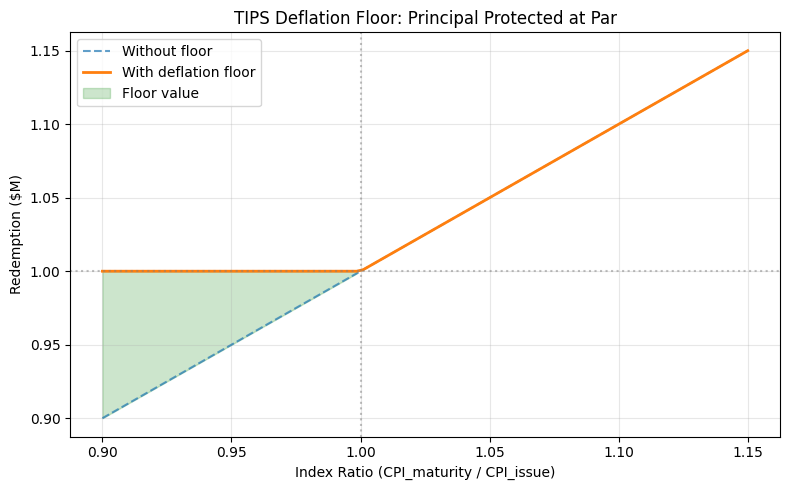

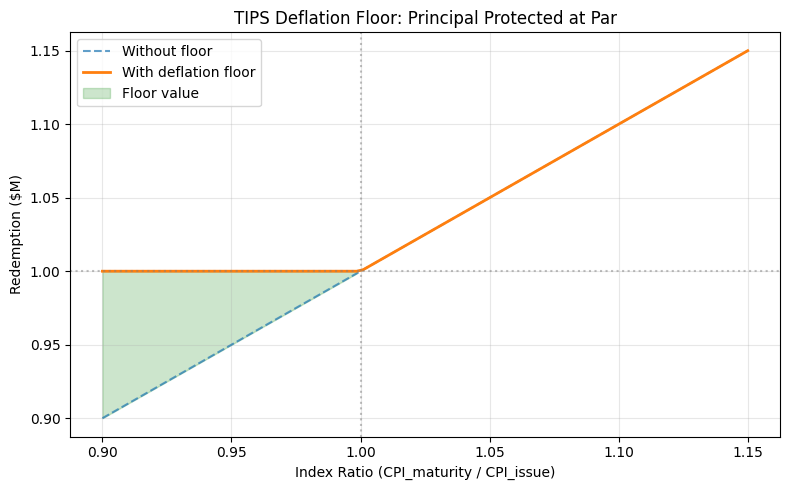

In [6]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Deflation floor illustration
index_ratios = np.linspace(0.90, 1.15, 100)
redemption_no_floor = 1_000_000 * index_ratios
redemption_with_floor = 1_000_000 * np.maximum(index_ratios, 1.0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(index_ratios, redemption_no_floor / 1e6, '--', label='Without floor', alpha=0.7)
ax.plot(index_ratios, redemption_with_floor / 1e6, '-', linewidth=2, label='With deflation floor')
ax.axvline(x=1.0, color='gray', linestyle=':', alpha=0.5)
ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.5)
ax.fill_between(index_ratios, redemption_no_floor / 1e6, redemption_with_floor / 1e6,
                where=index_ratios < 1.0, alpha=0.2, color='green', label='Floor value')
ax.set_xlabel('Index Ratio (CPI_maturity / CPI_issue)')
ax.set_ylabel('Redemption ($M)')
ax.set_title('TIPS Deflation Floor: Principal Protected at Par')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
print("The green region is the embedded option value from the deflation floor.")


## 5. Pricing a TIPS — Two Curves

Unlike nominal bonds (one discount curve), TIPS pricing requires **two curves**:

1. **Inflation curve (CPI):** Projects future CPI index levels to estimate indexed cashflows
2. **Real discount curve (TIPS yields):** Discounts the estimated real cashflows to present value

### Pricing formula (OpenGamma QR n.2 eq. 7)

$$PV = \sum_{i} C_i \times \text{IR}(t_i) \times P^R(0, t_i) \;+\; \text{Face} \times \max(\text{IR}(T), 1) \times P^R(0, T)$$

where:
- $C_i = \text{Face} \times r_{\text{real}} \times \text{YearFrac}_i$ (real coupon before indexing)
- $\text{IR}(t_i)$ = index ratio at payment date $t_i$
- $P^R(0, t_i)$ = real discount factor (from TIPS yield curve)

### Why a *real* discount curve?

TIPS yields are quoted in real terms. A TIPS yield of 2% means you earn 2% *above* inflation. Using the nominal Treasury curve would double-count inflation — the cashflows already include CPI indexation.

In [7]:
from fi_claude.market.snapshots import april_10_2026_snapshot

market = april_10_2026_snapshot()

print(f"Valuation date: {market.valuation_date}")
print()

# Inspect the USD-REAL (TIPS) curve
real_curve = market.discount_curves["USD-REAL"]
print(f"USD-REAL (TIPS yield) curve: {len(real_curve.nodes)} nodes")
print(f"{'Date':<14} {'DF':>12} {'Impl Yield':>12}")
print("-" * 40)
for node in real_curve.nodes:
    days = (node.date - real_curve.reference_date).days
    years = days / 365.25
    if years > 0.01:
        # Semi-annual: df = 1/(1+r/2)^(2*t), so r = 2*((1/df)^(1/(2t)) - 1)
        implied = 2.0 * ((1.0 / node.value) ** (1.0 / (2.0 * years)) - 1.0)
    else:
        implied = 0.0
    print(f"{node.date}   {node.value:>12.8f} {implied:>11.2%}")

print()

# Inspect the CPI curve
cpi_curve = market.inflation_curves["US-CPI"]
print(f"US-CPI curve: base level = {cpi_curve.base_index_level:.1f}")
print(f"{'Date':<14} {'CPI Level':>12} {'YoY Impl':>10}")
print("-" * 38)
for node in cpi_curve.nodes:
    days = (node.date - cpi_curve.reference_date).days
    years = days / 365.25
    if years > 0.5:
        ann_infl = (node.value / cpi_curve.base_index_level) ** (1.0 / years) - 1.0
    else:
        ann_infl = (node.value / cpi_curve.base_index_level - 1.0) / years if years > 0 else 0
    print(f"{node.date}   {node.value:>12.2f} {ann_infl:>9.2%}")

Valuation date: 2026-04-10

USD-REAL (TIPS yield) curve: 6 nodes
Date                     DF   Impl Yield
----------------------------------------
2026-04-10     1.00000000       0.00%
2031-04-10     0.91204842       1.85%
2033-04-10     0.87115801       1.98%
2036-04-09     0.81149540       2.10%
2046-04-10     0.63545094       2.28%
2056-04-10     0.49612753       2.35%

US-CPI curve: base level = 325.8
Date              CPI Level   YoY Impl
--------------------------------------
2026-07-10         328.41     3.21%
2026-10-10         331.01     3.22%
2027-04-10         336.55     3.30%
2028-04-10         347.30     3.25%
2031-04-10         381.19     3.19%
2036-04-10         443.09     3.12%


## 6. Building a TIPS Instrument

Let's construct a realistic 5-year TIPS and price it.

In [8]:
from datetime import date
from decimal import Decimal

from fi_claude.data.common import Currency, DayCountConvention
from fi_claude.data.instruments import (
    CouponScheduleEntry,
    InflationLagConvention,
    InflationLinkedBond,
)

# A 5-year TIPS issued April 15, 2024
# Real coupon: 1.875% (semi-annual, ACT/ACT)
# Base CPI at issue: ~308.0

issue = date(2024, 4, 15)
maturity = date(2029, 4, 15)

# Build the coupon schedule (semi-annual: Apr 15 and Oct 15)
# Generate all period boundaries from issue to maturity
boundaries = []
y = 2024
while True:
    d_apr = date(y, 4, 15)
    d_oct = date(y, 10, 15)
    if d_apr <= maturity:
        boundaries.append(d_apr)
    if d_oct <= maturity:
        boundaries.append(d_oct)
    if d_oct >= maturity:
        break
    y += 1

# Deduplicate and sort
boundaries = sorted(set(boundaries))

schedule = [
    CouponScheduleEntry(
        accrual_start=boundaries[i],
        accrual_end=boundaries[i + 1],
        payment_date=boundaries[i + 1],
    )
    for i in range(len(boundaries) - 1)
]

tips = InflationLinkedBond(
    face_value=Decimal("1_000_000"),
    real_coupon_rate=0.01875,      # 1.875% real
    issue_date=issue,
    maturity_date=maturity,
    currency=Currency.USD,
    day_count=DayCountConvention.ACT_ACT,
    base_cpi=308.0,
    inflation_lag=InflationLagConvention.THREE_MONTHS,
    coupon_frequency_months=6,
    deflation_floor=True,
    coupon_schedule=tuple(schedule),
)

print(f"TIPS Bond")
print(f"=========")
print(f"Face:          ${float(tips.face_value):>12,.0f}")
print(f"Real coupon:   {tips.real_coupon_rate:.3%}")
print(f"Issue:         {tips.issue_date}")
print(f"Maturity:      {tips.maturity_date}")
print(f"Base CPI:      {tips.base_cpi}")
print(f"Lag:           {tips.inflation_lag.value}")
print(f"Deflation fl:  {tips.deflation_floor}")
print(f"Coupons:       {len(tips.coupon_schedule)} periods")
print()
print("Coupon schedule:")
for i, entry in enumerate(schedule):
    past = " (past)" if entry.payment_date <= market.valuation_date else ""
    print(f"  {i+1:>2}. {entry.accrual_start} to {entry.accrual_end} pay {entry.payment_date}{past}")

TIPS Bond
Face:          $   1,000,000
Real coupon:   1.875%
Issue:         2024-04-15
Maturity:      2029-04-15
Base CPI:      308.0
Lag:           3M
Deflation fl:  True
Coupons:       10 periods

Coupon schedule:
   1. 2024-04-15 to 2024-10-15 pay 2024-10-15 (past)
   2. 2024-10-15 to 2025-04-15 pay 2025-04-15 (past)
   3. 2025-04-15 to 2025-10-15 pay 2025-10-15 (past)
   4. 2025-10-15 to 2026-04-15 pay 2026-04-15
   5. 2026-04-15 to 2026-10-15 pay 2026-10-15
   6. 2026-10-15 to 2027-04-15 pay 2027-04-15
   7. 2027-04-15 to 2027-10-15 pay 2027-10-15
   8. 2027-10-15 to 2028-04-15 pay 2028-04-15
   9. 2028-04-15 to 2028-10-15 pay 2028-10-15
  10. 2028-10-15 to 2029-04-15 pay 2029-04-15


## 7. Price the TIPS

Our pricer implements the OpenGamma formula:

$$PV = \sum_{\text{future coupons}} \text{Face} \times r \times \text{IR}(t_i) \times \text{YF}_i \times P^R(t_i) \;+\; \text{Face} \times \max(\text{IR}(T), 1) \times P^R(T)$$

In [9]:
from fi_claude.pricers.inflation_bond import price_inflation_linked_bond

result = price_inflation_linked_bond(tips, market)

print(f"Pricing Result")
print(f"==============")
print(f"Instrument:    {result.instrument_type}")
print(f"Valuation:     {result.valuation_date}")
print(f"Currency:      {result.currency.value}")
print(f"Present value: ${float(result.present_value):>12,.2f}")
print(f"Price (% par): {float(result.present_value) / float(tips.face_value) * 100:.4f}")
print()
print(f"Details:")
for k, v in result.details.items():
    print(f"  {k}: {v}")

Pricing Result
Instrument:    INFLATION_LINKED_BOND
Valuation:     2026-04-10
Currency:      USD
Present value: $1,172,802.32
Price (% par): 117.2802

Details:
  base_cpi: 308.0
  deflation_floor_active: 1.0


## 8. Cashflow Inspection

Let's examine each cashflow — the index ratio, nominal amount, and PV contribution.

In [10]:
print(f"{'Type':<10} {'Date':<12} {'Amount':>14} {'DF':>10} {'PV':>14}")
print("=" * 64)

total_coupon_pv = 0.0
principal_pv = 0.0

for cf in result.cashflows:
    pv = float(cf.present_value) if cf.present_value else 0.0
    df = cf.discount_factor or 0.0
    tp = cf.cashflow_type.value
    print(f"{tp:<10} {cf.payment_date}  ${float(cf.amount):>12,.2f} {df:>9.6f}  ${pv:>12,.2f}")
    
    if cf.cashflow_type.value == "COUPON":
        total_coupon_pv += pv
    else:
        principal_pv += pv

print("=" * 64)
print(f"  Coupon PV:    ${total_coupon_pv:>12,.2f}")
print(f"  Principal PV: ${principal_pv:>12,.2f}")
print(f"  Total PV:     ${float(result.present_value):>12,.2f}")

Type       Date                 Amount         DF             PV
COUPON     2026-04-15  $    9,968.75  0.999748  $    9,966.24
COUPON     2026-10-15  $   10,107.72  0.990566  $   10,012.37
COUPON     2027-04-15  $   10,220.45  0.981518  $   10,031.56
COUPON     2027-10-15  $   10,440.68  0.972504  $   10,153.61
COUPON     2028-04-15  $   10,590.49  0.963573  $   10,204.71
COUPON     2028-10-15  $   10,748.38  0.954723  $   10,261.73
COUPON     2029-04-15  $   10,874.99  0.946003  $   10,287.77
PRINCIPAL  2029-04-15  $1,164,778.95  0.946003  $1,101,884.34
  Coupon PV:    $   70,917.99
  Principal PV: $1,101,884.34
  Total PV:     $1,172,802.32


### Observations

1. **Coupon amounts grow** with each period as the projected CPI index rises (higher index ratio).
2. **Discount factors decrease** with maturity — longer-dated cashflows are worth less today.
3. **The principal dominates** — for a low-coupon TIPS (1.875%), the principal redemption is >90% of the PV.
4. The principal includes the inflation uplift: face x index ratio, protected by the deflation floor.

## 9. Shocking the Curves

TIPS have two risk dimensions:
- **Real rate risk (DV01):** sensitivity to TIPS yield changes
- **Inflation risk (IE01):** sensitivity to CPI curve shifts

### 9a. Real Rate Shocks

In [11]:
from fi_claude.risk.shocks import (
    apply_shocks, parallel, inflation_shock, scenario
)

def reprice(shocked_market, label):
    res = price_inflation_linked_bond(tips, shocked_market)
    delta = float(res.present_value - result.present_value)
    print(f"{label:<45} PV = ${float(res.present_value):>12,.2f}  (chg = ${delta:>+10,.2f})")
    return res

print(f"{'Scenario':<45} {'PV':>15}  {'Change':>14}")
print("=" * 80)

# Base
reprice(market, "Base")

# Real rate shocks
for bps in [25, 50, -25, -50]:
    s = scenario(rates=parallel("USD-REAL", bps))
    sign = "+" if bps > 0 else ""
    reprice(apply_shocks(market, s), f"Real rates {sign}{bps}bp")

Scenario                                                   PV          Change
Base                                          PV = $1,172,802.32  (chg = $     +0.00)
Real rates +25bp                              PV = $1,164,259.99  (chg = $ -8,542.33)
Real rates +50bp                              PV = $1,155,781.24  (chg = $-17,021.08)
Real rates -25bp                              PV = $1,181,408.70  (chg = $ +8,606.38)
Real rates -50bp                              PV = $1,190,079.62  (chg = $+17,277.30)


### 9b. Inflation Curve Shocks (IE01)

In [12]:
print(f"{'Scenario':<45} {'PV':>15}  {'Change':>14}")
print("=" * 80)

reprice(market, "Base")

# Inflation shocks: CPI level shifts
for bps in [50, 100, -50, -100]:
    s = scenario(inflation=inflation_shock("US-CPI", bps))
    sign = "+" if bps > 0 else ""
    reprice(apply_shocks(market, s), f"CPI {sign}{bps}bp")

Scenario                                                   PV          Change
Base                                          PV = $1,172,802.32  (chg = $     +0.00)
CPI +50bp                                     PV = $1,178,666.33  (chg = $ +5,864.01)
CPI +100bp                                    PV = $1,184,530.35  (chg = $+11,728.03)
CPI -50bp                                     PV = $1,166,938.31  (chg = $ -5,864.01)
CPI -100bp                                    PV = $1,161,074.30  (chg = $-11,728.02)


### 9c. Combined Scenarios

In [13]:
print(f"{'Scenario':<45} {'PV':>15}  {'Change':>14}")
print("=" * 80)

reprice(market, "Base")

# Disinflation: real rates up 50bp + CPI down 100bp
s_disinfl = scenario(
    "Disinflation",
    rates=parallel("USD-REAL", 50),
    inflation=inflation_shock("US-CPI", -100),
)
reprice(apply_shocks(market, s_disinfl), "Disinflation (+50bp real, -100bp CPI)")

# Reflation: real rates down 25bp + CPI up 100bp
s_reflat = scenario(
    "Reflation",
    rates=parallel("USD-REAL", -25),
    inflation=inflation_shock("US-CPI", 100),
)
reprice(apply_shocks(market, s_reflat), "Reflation (-25bp real, +100bp CPI)")

# Stagflation: real rates up 50bp + CPI up 200bp
s_stagfl = scenario(
    "Stagflation",
    rates=parallel("USD-REAL", 50),
    inflation=inflation_shock("US-CPI", 200),
)
reprice(apply_shocks(market, s_stagfl), "Stagflation (+50bp real, +200bp CPI)")

Scenario                                                   PV          Change
Base                                          PV = $1,172,802.32  (chg = $     +0.00)
Disinflation (+50bp real, -100bp CPI)         PV = $1,144,223.43  (chg = $-28,578.89)
Reflation (-25bp real, +100bp CPI)            PV = $1,193,222.79  (chg = $+20,420.47)
Stagflation (+50bp real, +200bp CPI)          PV = $1,178,896.86  (chg = $ +6,094.54)


PricingResult(instrument_type='INFLATION_LINKED_BOND', valuation_date=datetime.date(2026, 4, 10), currency=<Currency.USD: 'USD'>, present_value=Decimal('1178896.86'), cashflows=(Cashflow(payment_date=datetime.date(2026, 4, 15), amount=Decimal('10168.12'), currency=<Currency.USD: 'USD'>, cashflow_type=<CashflowType.COUPON: 'COUPON'>, label='coupon 2025-10-15 to 2026-04-15', accrual_start=datetime.date(2025, 10, 15), accrual_end=datetime.date(2026, 4, 15), discount_factor=0.9996795180114351, present_value=Decimal('10164.87')), Cashflow(payment_date=datetime.date(2026, 10, 15), amount=Decimal('10309.87'), currency=<Currency.USD: 'USD'>, cashflow_type=<CashflowType.COUPON: 'COUPON'>, label='coupon 2026-04-15 to 2026-10-15', accrual_start=datetime.date(2026, 4, 15), accrual_end=datetime.date(2026, 10, 15), discount_factor=0.9880202810105416, present_value=Decimal('10186.36')), Cashflow(payment_date=datetime.date(2027, 4, 15), amount=Decimal('10424.86'), currency=<Currency.USD: 'USD'>, cashf

## 10. DV01 and IE01

**DV01** = PV change per 1bp parallel shift in real rates.

**IE01** = PV change per 1bp shift in CPI levels.

These two sensitivities are the primary risk metrics for TIPS.

In [14]:
base_pv = float(result.present_value)

# DV01: real rate sensitivity
up_1bp = apply_shocks(market, scenario(rates=parallel("USD-REAL", 1)))
dn_1bp = apply_shocks(market, scenario(rates=parallel("USD-REAL", -1)))
pv_up = float(price_inflation_linked_bond(tips, up_1bp).present_value)
pv_dn = float(price_inflation_linked_bond(tips, dn_1bp).present_value)
dv01 = (pv_up - pv_dn) / 2.0

# IE01: inflation sensitivity
infl_up = apply_shocks(market, scenario(inflation=inflation_shock("US-CPI", 1)))
infl_dn = apply_shocks(market, scenario(inflation=inflation_shock("US-CPI", -1)))
pv_infl_up = float(price_inflation_linked_bond(tips, infl_up).present_value)
pv_infl_dn = float(price_inflation_linked_bond(tips, infl_dn).present_value)
ie01 = (pv_infl_up - pv_infl_dn) / 2.0

print(f"Risk Metrics ($1M face TIPS, 1.875% real, ~3Y remaining)")
print(f"========================================================")
print(f"DV01 (real rate): ${dv01:>10,.2f} per 1bp")
print(f"IE01 (CPI level): ${ie01:>10,.2f} per 1bp")
print()
print(f"DV01 is {'negative' if dv01 < 0 else 'positive'}: real rates up -> bond PV {'down' if dv01 < 0 else 'up'}")
print(f"IE01 is {'positive' if ie01 > 0 else 'negative'}: CPI up -> bond PV {'up' if ie01 > 0 else 'down'}")
print()
print(f"Interpretation:")
print(f"  A 10bp rise in real yields costs ~${abs(dv01) * 10:,.0f}")
print(f"  A 10bp rise in CPI levels gains ~${abs(ie01) * 10:,.0f}")

Risk Metrics ($1M face TIPS, 1.875% real, ~3Y remaining)
DV01 (real rate): $   -342.97 per 1bp
IE01 (CPI level): $    117.28 per 1bp

DV01 is negative: real rates up -> bond PV down
IE01 is positive: CPI up -> bond PV up

Interpretation:
  A 10bp rise in real yields costs ~$3,430
  A 10bp rise in CPI levels gains ~$1,173


## 11. Breakeven Inflation

The **breakeven inflation rate** is the inflation rate at which a TIPS and a nominal Treasury of the same maturity have equal returns.

$$\text{Breakeven} \approx \text{Nominal yield} - \text{TIPS real yield}$$

This is the Fisher equation decomposition. If realized inflation exceeds the breakeven, TIPS outperform. If inflation undershoots, nominal bonds win.

### From our market data

In [15]:
from fi_claude.curves.interpolation import interpolate_discount_factor
from datetime import timedelta

nominal_curve = market.discount_curves["USD"]
real_curve = market.discount_curves["USD-REAL"]

print(f"Breakeven Inflation (Nominal yield - TIPS real yield)")
print(f"=====================================================")
print(f"{'Tenor':<8} {'Nom DF':>10} {'Real DF':>10} {'Nom Yld':>10} {'Real Yld':>10} {'Breakeven':>10}")
print("-" * 62)

for years in [3, 5, 7, 10, 20, 30]:
    target = market.valuation_date + timedelta(days=round(years * 365.25))
    
    df_nom = interpolate_discount_factor(nominal_curve, target)
    df_real = interpolate_discount_factor(real_curve, target)
    
    # Semi-annual implied yields
    if years > 0:
        nom_yield = 2.0 * ((1.0 / df_nom) ** (1.0 / (2.0 * years)) - 1.0)
        real_yield = 2.0 * ((1.0 / df_real) ** (1.0 / (2.0 * years)) - 1.0)
    else:
        nom_yield = real_yield = 0.0
    
    breakeven = nom_yield - real_yield
    
    print(f"{years}Y{'':<5} {df_nom:>10.6f} {df_real:>10.6f} "
          f"{nom_yield:>9.2%} {real_yield:>9.2%} {breakeven:>9.2%}")

print()
print("Interpretation:")
print("  If you expect inflation above the breakeven, buy TIPS.")
print("  If you expect inflation below the breakeven, buy nominal Treasuries.")

Breakeven Inflation (Nominal yield - TIPS real yield)
Tenor        Nom DF    Real DF    Nom Yld   Real Yld  Breakeven
--------------------------------------------------------------
3Y        0.892559   0.946241     3.82%     1.85%     1.97%
5Y        0.822827   0.912048     3.94%     1.85%     2.09%
7Y        0.751589   0.871158     4.12%     1.98%     2.14%
10Y        0.652432   0.811495     4.32%     2.10%     2.22%
20Y        0.379622   0.635451     4.90%     2.28%     2.62%
30Y        0.233063   0.496128     4.91%     2.35%     2.56%

Interpretation:
  If you expect inflation above the breakeven, buy TIPS.
  If you expect inflation below the breakeven, buy nominal Treasuries.


## 12. Seasoning — Theta and Carry

How does the TIPS value evolve with the passage of time?

In [16]:
from functools import partial
from fi_claude.risk.seasoning import compute_seasoning

pricer = partial(price_inflation_linked_bond, tips)

for days in [7, 30, 90]:
    h = compute_seasoning(
        pricer, market, horizon_days=days,
        rate_curve_keys=("USD-REAL",),
    )
    base_dv01 = h.base_risk.dv01.get("USD-REAL", 0.0)
    horizon_dv01 = h.horizon_risk.dv01.get("USD-REAL", 0.0)
    print(f"--- {days}-day horizon ---")
    print(f"  Base PV:      ${h.base_pv:>12,.2f}")
    print(f"  Horizon PV:   ${h.horizon_pv:>12,.2f}")
    print(f"  Total theta:  ${h.total_theta:>12,.2f}")
    print(f"  Carry:        ${h.carry:>12,.2f}")
    print(f"  Rolldown:     ${h.rolldown:>12,.2f}")
    print(f"  Base DV01:    ${base_dv01:>12,.4f}")
    print(f"  Horizon DV01: ${horizon_dv01:>12,.4f}")
    print()

--- 7-day horizon ---
  Base PV:      $1,172,802.32
  Horizon PV:   $1,162,543.63
  Total theta:  $  -10,258.69
  Carry:        $    9,968.75
  Rolldown:     $  -20,227.44
  Base DV01:    $   -342.9200
  Horizon DV01: $   -340.5900

--- 30-day horizon ---
  Base PV:      $1,172,802.32
  Horizon PV:   $1,161,581.51
  Total theta:  $  -11,220.81
  Carry:        $    9,968.75
  Rolldown:     $  -21,189.56
  Base DV01:    $   -342.9200
  Horizon DV01: $   -333.0000

--- 90-day horizon ---
  Base PV:      $1,172,802.32
  Horizon PV:   $1,159,053.75
  Total theta:  $  -13,748.57
  Carry:        $    9,968.75
  Rolldown:     $  -23,717.32
  Base DV01:    $   -342.9200
  Horizon DV01: $   -313.2400



## 13. Convention Comparison: US TIPS vs UK Linkers vs French OATi

The same concept — inflation protection — is implemented differently across markets.

| Feature | US TIPS | UK Index-Linked Gilts | French OATi |
|---------|---------|----------------------|-------------|
| **Index** | CPI-U (All Urban Consumers) | RPI (Retail Prices Index) | HICP-x (EU Harmonised, ex-tobacco) |
| **Lag** | 3 months, daily interpolated | 3M (new) or 8M (pre-2005) | 3 months, daily interpolated |
| **Deflation floor** | Yes (principal) | No (old issues), Yes (new) | Yes (principal) |
| **Coupon frequency** | Semi-annual | Semi-annual | Annual |
| **Day count** | ACT/ACT | ACT/ACT | ACT/ACT |
| **Real coupon quote** | Clean real price | Clean real price | Clean real price |
| **Reference period** | 3 months before settlement | 3 or 8 months before | 3 months before |

*Source: OpenGamma QR n.2, Table 1; Bloomberg TIPS Primer*

### Key Differences

1. **RPI vs CPI:** UK RPI includes mortgage interest payments, making it systematically higher than CPI. This means UK linkers accrue inflation faster.

2. **8-month lag (old UK):** Pre-2005 UK linkers use an 8-month lag, which makes the CPI reference *very* stale. The indexation barely responds to current inflation.

3. **Annual vs semi-annual:** French OATi pay once per year, concentrating coupon risk on a single date.

4. **Deflation floor value:** Without a floor (old UK linkers), the bond can return less than par in a sustained deflation. This makes the floor option embedded in US TIPS non-trivial.

## Summary

### The Pipeline: CPI Data + TIPS Yields -> Pricing

```
BLS CPI-U releases      bootstrap.py         market.py          pricers/
-------------------  ------------------   ---------------    ----------------
CPI monthly index    -> InflationCurve    -> MarketData   -> price_inflation_
                        (projected levels)                    linked_bond()
TIPS real yields     -> DiscountCurve                         CALCULATION
  (treasury.gov)        (USD-REAL)             DATA              |
  ACTION                 CALCULATION                        PricingResult
```

### Pricing Formula (OpenGamma QR n.2)

$$PV = \sum_{i} C_i \times \frac{\text{CPI}(t_i)}{\text{CPI}_{\text{base}}} \times P^R(0, t_i) \;+\; F \times \max\left(\frac{\text{CPI}(T)}{\text{CPI}_{\text{base}}}, 1\right) \times P^R(0, T)$$

### TIPS-Specific Gotchas

1. **Two curves, not one.** Use a *real* discount curve (TIPS yields), not the nominal Treasury curve. Double-counting inflation is the #1 TIPS pricing mistake.
2. **3-month CPI lag.** The reference index for April uses January/February CPI. Your CPI curve must project future values — the lag doesn't eliminate estimation.
3. **Daily interpolation.** Unlike most fixed-income accrual (which counts days), the CPI reference moves daily between two monthly anchor points.
4. **Deflation floor is an option.** It has value (especially for near-par TIPS in low-inflation regimes) and should be modeled, not ignored.
5. **Breakeven = nominal minus real.** The Fisher equation gives the market-implied inflation rate. Above it, TIPS win.

### References

- **OpenGamma QR n.2** — *"Inflation Instruments: Bonds and Swaps"* (Henrard, 2013): https://quant.opengamma.io/Inflation-Instruments-OpenGamma.pdf
- **OpenGamma QR** — *"Interest Rate Instruments and Market Conventions"* (Henrard, 2013): https://quant.opengamma.io/Interest-Rate-Instruments-and-Market-Conventions.pdf
- **US Treasury** — TIPS methodology: https://www.treasurydirect.gov/marketable-securities/tips/
- **BLS** — CPI-U data: https://www.bls.gov/cpi/
- **Strata** — `DiscountingCapitalIndexedBondProductPricer`: https://strata.opengamma.io/